# 추출 경로별 결과 확인 — PDF 표 / HWP 표 / 이미지

같은 원본에서 나온 것이라도 **어떤 형태로 저장돼 있느냐**에 따라 꺼내는 방법이 다르다.

| 대상 | 방법 | 원리 | 건수 |
|---|---|---|---|
| PDF 표 | `pymupdf_find_tables` | PDF 텍스트 레이어의 셀 좌표를 읽음 | 740 |
| HWP 표 | HWP 레코드 직접 파싱 | HWP 파일의 `TABLE`/`LIST_HEADER` 레코드를 읽음 | 9,451 |
| 이미지 | `openai_only` | 픽셀을 보고 글자·구조를 알아냄 | 182 |

앞의 둘은 **파일에 적힌 값을 꺼내는 것**이라 오독이 없고, 이미지만 **알아맞히는 것**이라 오류 가능성이 있다.


In [1]:
import base64
import io
import json
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display
from PIL import Image

DATA_DIR = Path.home() / "vision_cmp"

# 1) PDF 표 — 이미 파이프라인이 만들어 둔 산출물
pdf_tables = [
    row
    for row in (json.loads(line) for line in open("/data/processed/table_documents.jsonl", encoding="utf-8"))
    if row["extraction_method"] == "pymupdf_find_tables" and row["table_markdown"].strip()
]

# 2) HWP 표 — 직접 파싱 결과. 1행/1열은 꾸미기용이라 제외한다.
hwp_tables = [
    row
    for row in (json.loads(line) for line in open(DATA_DIR / "hwp_tables.jsonl", encoding="utf-8"))
    if row["rows"] > 1 and row["columns"] > 1
]

# 3) 이미지 — openai_only 벤치마크 결과
image_rows = json.loads((DATA_DIR / "bench_openai_only.json").read_text(encoding="utf-8"))["rows"]
image_dir = DATA_DIR / "bench_src"

print(f"PDF 표   {len(pdf_tables):,}개")
print(f"HWP 표   {len(hwp_tables):,}개")
print(f"이미지    {len(image_rows):,}장")

PDF 표   740개
HWP 표   9,451개
이미지    15장


## 0. 크기 분포 — 청크로 넣을 때 분할이 필요한지 본다

In [2]:
sizes = pd.DataFrame(
    {
        "PDF 표": pd.Series([len(t["table_markdown"]) for t in pdf_tables]),
        "HWP 표": pd.Series([t["markdown_length"] for t in hwp_tables]),
    }
).describe().round(0)

over = pd.DataFrame(
    {
        "PDF 표": [
            sum(1 for t in pdf_tables if len(t["table_markdown"]) > 800),
            sum(1 for t in pdf_tables if len(t["table_markdown"]) > 1600),
        ],
        "HWP 표": [
            sum(1 for t in hwp_tables if t["markdown_length"] > 800),
            sum(1 for t in hwp_tables if t["markdown_length"] > 1600),
        ],
    },
    index=["800자 초과", "1,600자 초과"],
)
display(sizes, over)

,PDF 표,HWP 표
count,740.0,9451.0
mean,500.0,565.0
std,380.0,598.0
min,35.0,15.0
25%,214.0,260.0
50%,404.0,401.0
75%,700.0,661.0
max,4237.0,9596.0


,PDF 표,HWP 표
800자 초과,131,1713
"1,600자 초과",8,433


In [3]:
def escape(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def block(title: str, subtitle: str, body: str, image_path=None) -> None:
    """추출 결과를 원문 그대로 보여준다. 청크에 들어갈 형태가 이것이다."""
    picture = ""
    if image_path is not None:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            ratio = 420 / image.width
            if ratio < 1:
                image = image.resize((420, int(image.height * ratio)))
            buffer = io.BytesIO()
            image.save(buffer, format="JPEG", quality=80)
        encoded = base64.b64encode(buffer.getvalue()).decode()
        picture = (
            f'<img src="data:image/jpeg;base64,{encoded}" '
            'style="border:1px solid #999; border-radius:6px; flex:0 0 auto;">'
        )

    display(HTML(f"""
    <div style="margin:20px 0;">
      <div style="font-weight:bold; margin-bottom:2px;">{escape(title)}</div>
      <div style="font-size:12px; margin-bottom:8px;">{escape(subtitle)}</div>
      <div style="display:flex; gap:12px; align-items:flex-start;">
        {picture}
        <pre style="flex:1; min-width:0; white-space:pre; overflow:auto; max-height:460px;
                    font-size:12px; margin:0; padding:10px; border:1px solid #ccc;
                    border-radius:6px;">{escape(body)}</pre>
      </div>
    </div>"""))

## 1. PDF 표 — PyMuPDF

PDF 안에 셀 좌표가 저장돼 있어 그대로 읽는다. 인식이나 추측 과정이 없다.

왼쪽은 원본 PDF에서 표 영역만 잘라낸 것이다. `find_tables()`가 잡은 좌표를 그대로 써서 렌더링했으므로,
**왼쪽 이미지의 범위 자체가 표 인식 결과**이기도 하다.


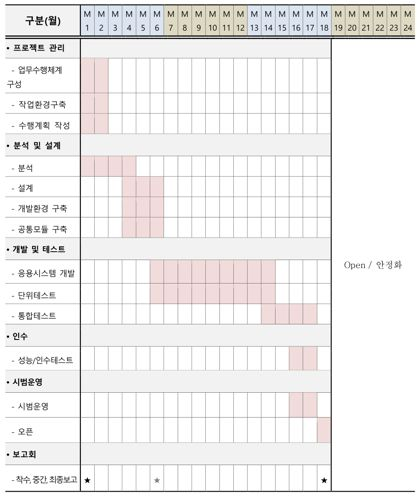


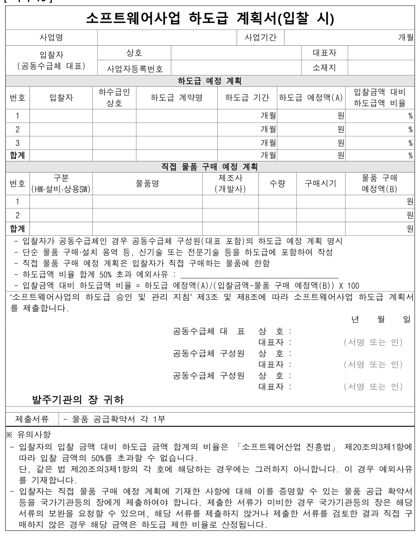


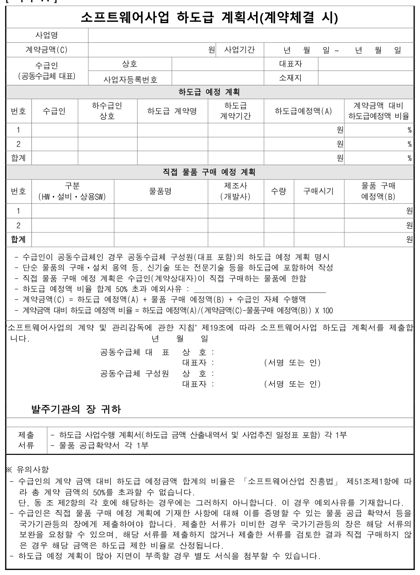

In [4]:
pdf_capture_dir = DATA_DIR / "pdf_capture"

for table in sorted(pdf_tables, key=lambda t: len(t["table_markdown"]), reverse=True)[:3]:
    name = f"{table['doc_id']}_p{int(table['page_number'])}_t{int(table['table_number'])}.png"
    capture = pdf_capture_dir / name
    block(
        f"{table['doc_id']}  {table['page_number']}쪽  표 {table['table_number']}번",
        f"{table['file_name']}  ({len(table['table_markdown'])}자)",
        table["table_markdown"],
        image_path=capture if capture.exists() else None,
    )

## 2. HWP 표 — 레코드 직접 파싱

HWP 파일의 `TABLE` 레코드에서 행·열 수를, `LIST_HEADER` 레코드에서 각 셀의 좌표를 읽어 격자에 배치한다.
현재 본문 추출은 이 정보를 버리고 글자만 가져와서 표가 한 줄로 뭉개진다.

왼쪽이 한글에서 캡처한 원본, 오른쪽이 파싱 결과다. 100행이 넘는 표는 캡처 범위에 맞춰 앞부분만 보여준다.


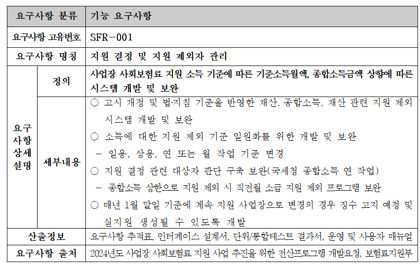


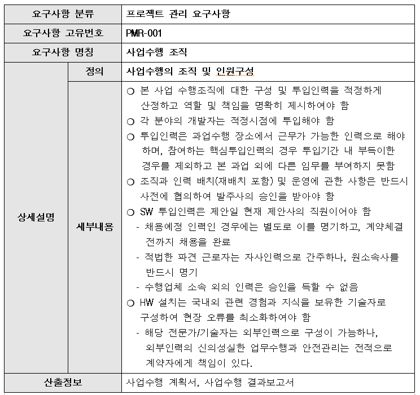


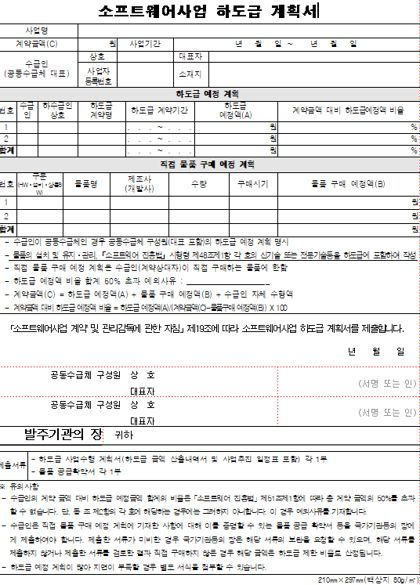


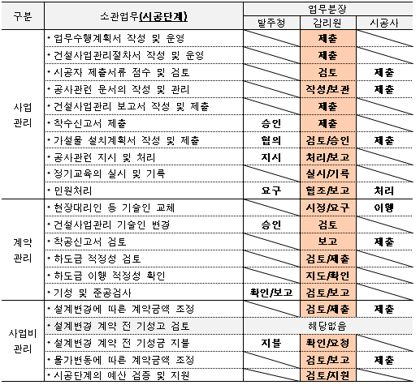

In [5]:
CAPTURED = [
    ("doc_050", 17, "요구사항 명세(SFR-001)", 9),
    ("doc_065", 36, "요구사항 명세(PMR-001)", 8),
    ("doc_085", 119, "하도급 계획서 (중첩 표)", None),
    ("doc_015", 46, "건설사업관리 업무분장 (중첩 표)", None),
]
capture_dir = DATA_DIR / "hwp_capture"
by_key = {(t["doc_id"], t["table_number"]): t for t in hwp_tables}

for doc_id, number, label, limit in CAPTURED:
    table = by_key[(doc_id, number)]
    lines = table["markdown"].splitlines()
    body = "\n".join(lines[:limit]) if limit else table["markdown"]
    if limit and len(lines) > limit:
        body += f"\n... (이하 {len(lines) - limit}행 생략)"
    block(
        f"{doc_id}  표 {number}번  —  {label}",
        f"{table['rows']}행 x {table['columns']}열 / 셀 {table['cells_found']}개 수집 "
        f"/ {table['cells_placed']}개 배치 / 내용 있는 셀 {table['cells_filled']}개",
        body,
        image_path=capture_dir / f"{doc_id}_t{number}.png",
    )

캡처와 대조하면 확인되는 것들이다.

- **병합 셀** — `요구사항 상세설명`이 여러 행에 걸쳐 있다. 첫 행에만 값이 있고 나머지는 비어 있는 게 정상이다.
- **중첩 표** — `doc_085`, `doc_015`는 표 안에 표가 있는 구조다. 바깥 표의 셀 안에 안쪽 표가 들어간다.
- **빈 서식 칸** — 하도급 계획서처럼 값을 적지 않은 서식은 칸만 있고 내용이 없다.

### 걸러낸 표 — 1행 또는 1열

HWP는 제목에 테두리를 넣거나 여백을 맞추려고 표를 쓰는 일이 많다. 내용이 아니라 서식이라 청크에 넣지 않는다.

In [6]:
layout = [
    row
    for row in (json.loads(line) for line in open(DATA_DIR / "hwp_tables.jsonl", encoding="utf-8"))
    if row["rows"] <= 1 or row["columns"] <= 1
]
print(f"제외 대상 {len(layout):,}개 — 아래는 그중 3개")
for table in layout[:3]:
    block(
        f"{table['doc_id']}  표 {table['table_number']}번  ({table['rows']}행 x {table['columns']}열)",
        "서식용으로 판단해 제외",
        table["markdown"][:400],
    )

제외 대상 2,479개 — 아래는 그중 3개


## 3. 이미지 — openai_only

파일에 글자 데이터가 없어 픽셀을 보고 알아내야 한다. 표·서식·도식·사진이 모두 여기로 온다.
왼쪽이 원본, 오른쪽이 추출 결과다.


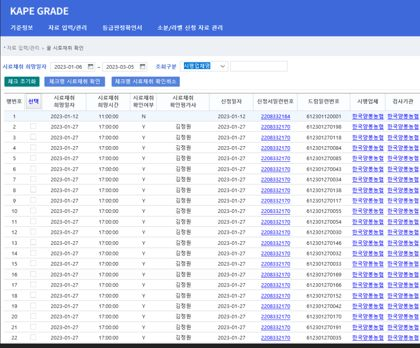


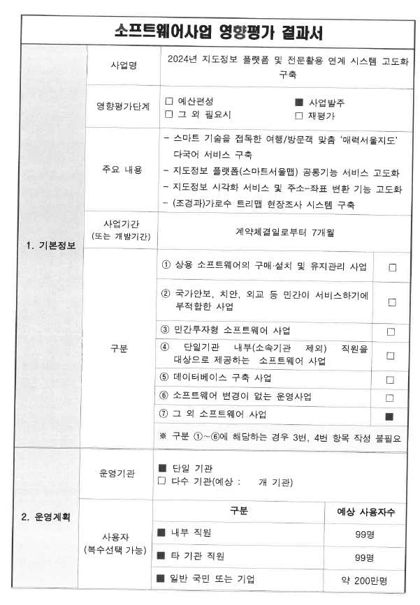


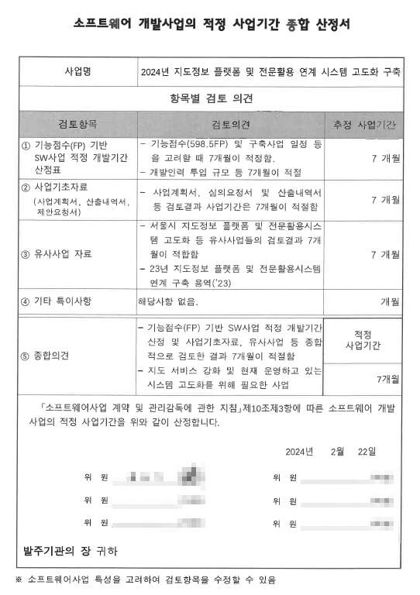


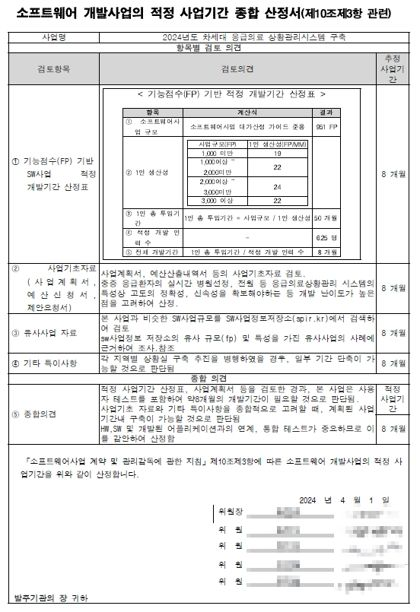


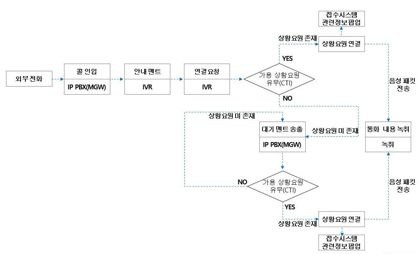


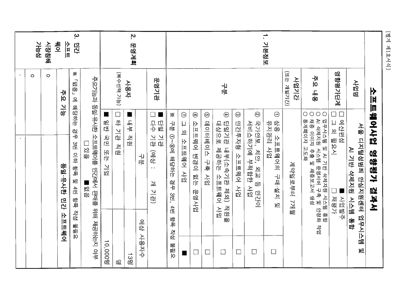


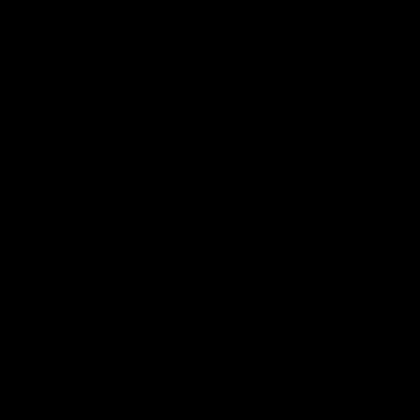

In [7]:
order = [155, 98, 97, 144, 150, 141, 157]
by_index = {row["index"]: row for row in image_rows}
files = {int(path.name[:3]): path for path in image_dir.iterdir()}

for index in order:
    row = by_index[index]
    block(
        f"#{index:03d}  판정: {row['image_type']}",
        f"{row['text_length']}자 / {row['latency_sec']}초",
        row["ocr_text"] or "(글자 없음)",
        image_path=files.get(index),
    )

## 정리

```
PDF 표      PyMuPDF                    파일에서 꺼냄. 오독 없음
HWP 표      레코드 직접 파싱             파일에서 꺼냄. 오독 없음
이미지       openai_only                픽셀을 보고 알아냄. 오류 가능
```

이미지 경로만 검증이 필요하다. `#144`에서 `6.25 명`을 `62.5일`로, `50 개월`을 `50.7월`로 읽은 오류가 확인됐다.
표가 파일 안에 글자로 저장돼 있다면 이미지 경로를 쓰지 않는 이유가 이것이다.
